In [1]:
import pandas as pd
import plotly.express as px
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()

# Convert to a pandas DataFrame (a table we can work with)
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Check for missing values and data types
print("Missing values in each column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Data types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Basic statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


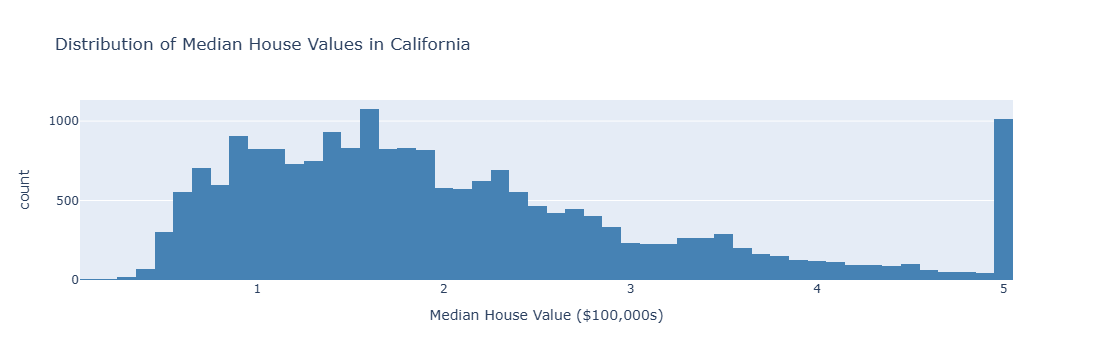

In [3]:
# Visualise the distribution of house prices (our target variable)
# This tells us what we are trying to predict
fig = px.histogram(
    df, 
    x='MedHouseVal', 
    nbins=50,
    title='Distribution of Median House Values in California',
    labels={'MedHouseVal': 'Median House Value ($100,000s)'},
    color_discrete_sequence=['steelblue']
)
fig.show()

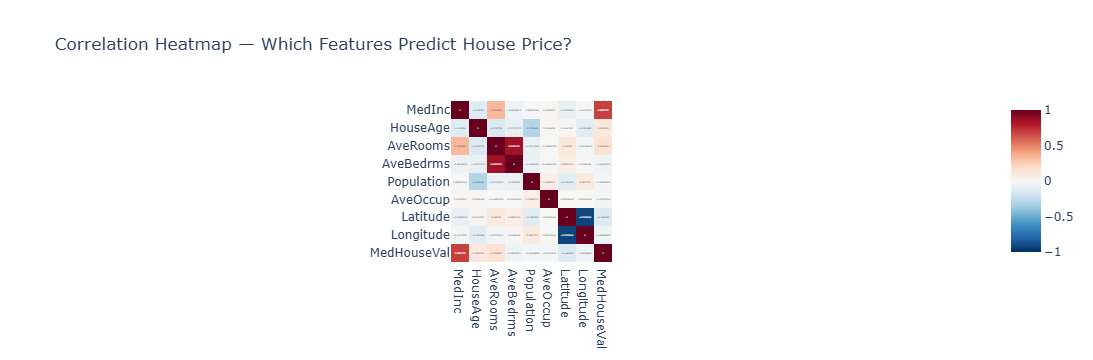

In [4]:
# Visualise how each feature correlates with house price
# Correlation: a number from -1 to 1 showing how strongly two things move together
corr = df.corr()

fig = px.imshow(
    corr,
    title='Correlation Heatmap — Which Features Predict House Price?',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    text_auto=True
)
fig.show()

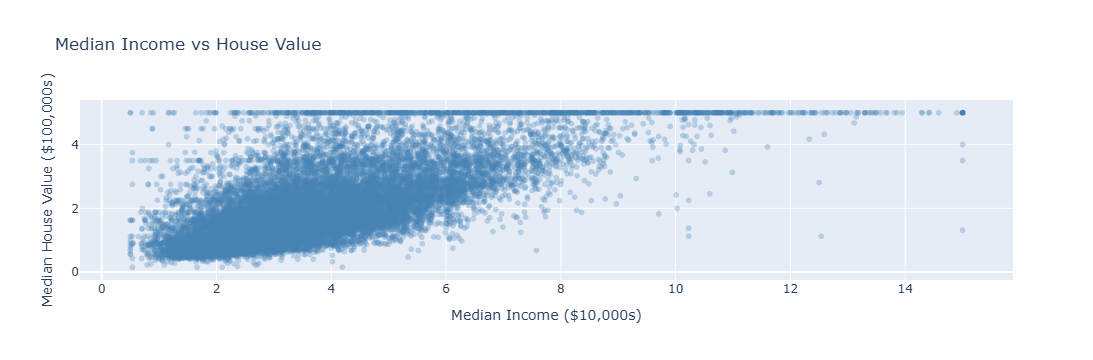

In [5]:
# Scatter plot: Income vs House Price
# This is the most important relationship in the dataset
fig = px.scatter(
    df,
    x='MedInc',
    y='MedHouseVal',
    opacity=0.3,
    title='Median Income vs House Value',
    labels={
        'MedInc': 'Median Income ($10,000s)',
        'MedHouseVal': 'Median House Value ($100,000s)'
    },
    color_discrete_sequence=['steelblue']
)
fig.show()

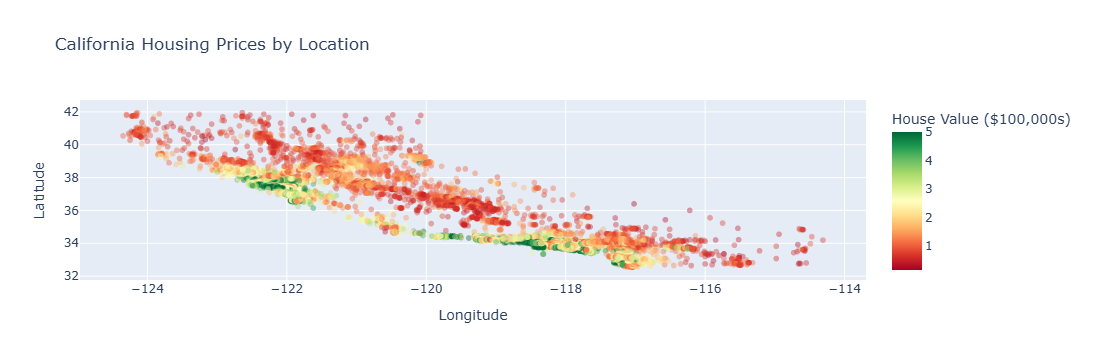

In [6]:
# Map of California — colour shows house price by location
fig = px.scatter(
    df,
    x='Longitude',
    y='Latitude',
    color='MedHouseVal',
    opacity=0.4,
    title='California Housing Prices by Location',
    labels={'MedHouseVal': 'House Value ($100,000s)'},
    color_continuous_scale='RdYlGn'
)
fig.show()

In [1]:
# We need to reload everything since we reopened the notebook
import pandas as pd
import plotly.express as px
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Data reloaded. Shape:", df.shape)

Data reloaded. Shape: (20640, 9)


In [2]:
# Remove capped house values
# Any row where MedHouseVal = 5.0 is artificially capped — not a real price
print("Rows before removing cap:", len(df))
df = df[df['MedHouseVal'] < 5.0]
print("Rows after removing cap:", len(df))
print("Rows removed:", 20640 - len(df))

Rows before removing cap: 20640
Rows after removing cap: 19648
Rows removed: 992


In [3]:
# Create 3 new features
df['rooms_per_person'] = df['AveRooms'] / df['AveOccup']
df['bedrooms_ratio'] = df['AveBedrms'] / df['AveRooms']
df['income_per_occupant'] = df['MedInc'] / df['AveOccup']

print("New shape:", df.shape)
print("\nNew columns added:")
print(df[['rooms_per_person', 'bedrooms_ratio', 'income_per_occupant']].head())

New shape: (19648, 12)

New columns added:
   rooms_per_person  bedrooms_ratio  income_per_occupant
0          2.732919        0.146591             3.257687
1          2.956685        0.155797             3.934608
2          2.957661        0.129516             2.589838
3          2.283154        0.184458             2.214765
4          2.879646        0.172096             1.763125


In [4]:
# Check for any bad values created by our division operations
# Division can sometimes create infinity or NaN (Not a Number) values
print("Any infinite values:", (df == float('inf')).sum().sum())
print("Any NaN values:", df.isnull().sum().sum())
print("\nBasic stats on new features:")
df[['rooms_per_person', 'bedrooms_ratio', 'income_per_occupant']].describe()

Any infinite values: 0
Any NaN values: 0

Basic stats on new features:


,rooms_per_person,bedrooms_ratio,income_per_occupant
count,19648.000000,19648.000000,19648.000000
mean,1.938814,0.214962,1.324343
std,1.100585,0.056971,0.628345
min,0.002547,0.100000,0.008225
25%,1.498461,0.177648,0.848364
50%,1.911020,0.204555,1.256771
75%,2.248384,0.240908,1.703736
max,55.222222,1.000000,7.462508


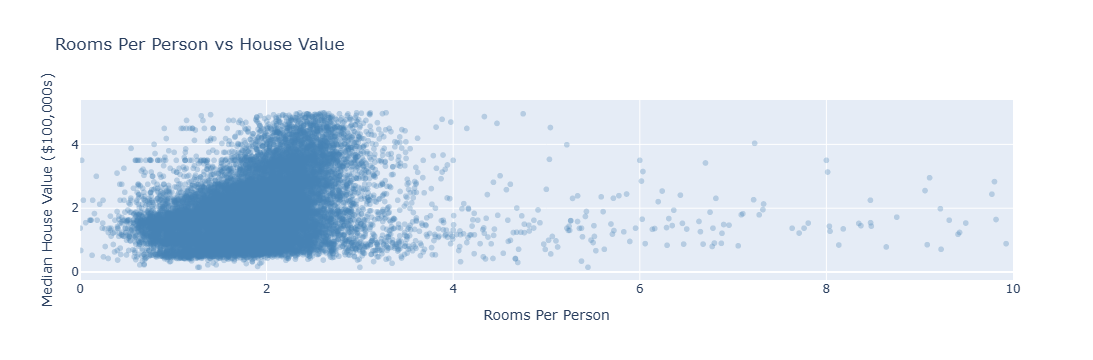

In [5]:
# Visualise our new feature: rooms_per_person vs house value
fig = px.scatter(
    df,
    x='rooms_per_person',
    y='MedHouseVal',
    opacity=0.3,
    title='Rooms Per Person vs House Value',
    labels={
        'rooms_per_person': 'Rooms Per Person',
        'MedHouseVal': 'Median House Value ($100,000s)'
    },
    color_discrete_sequence=['steelblue']
)
fig.update_xaxes(range=[0, 10])  # Limit x axis to ignore extreme outliers
fig.show()

In [6]:
# Save the clean dataset to a CSV file
# CSV = Comma Separated Values — a simple table format any tool can read
df.to_csv('housing_clean.csv', index=False)

print("File saved successfully.")
print("Shape of saved data:", df.shape)
print("Columns saved:", list(df.columns))

File saved successfully.
Shape of saved data: (19648, 12)
Columns saved: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'rooms_per_person', 'bedrooms_ratio', 'income_per_occupant']


In [8]:
# Load the clean dataset we saved on Day 2
import pandas as pd

df = pd.read_csv('housing_clean.csv')
print("Data loaded. Shape:", df.shape)
print("Columns:", list(df.columns))

Data loaded. Shape: (19648, 12)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'rooms_per_person', 'bedrooms_ratio', 'income_per_occupant']


In [9]:
# Split data into features (X) and target (y)
# X = everything the model uses to make predictions
# y = the answer we want the model to predict

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19648, 11)
y shape: (19648,)


In [10]:
# Split into training set and test set
# Training set: model learns from this (80%)
# Test set: model gets tested on this — it has never seen these rows (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 15718
Test rows: 3930


In [11]:
# Train all 4 models and score them
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # cross_val_score splits training data into 5 parts and tests 5 times
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    results[name] = scores.mean()
    print(f"{name}: R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")

Linear Regression: R2 = 0.6387 (+/- 0.0147)
Ridge Regression: R2 = 0.6387 (+/- 0.0146)
Random Forest: R2 = 0.7939 (+/- 0.0103)
XGBoost: R2 = 0.8068 (+/- 0.0099)


In [12]:
# Train XGBoost on full training set and evaluate on test set
# Cross-validation gave us confidence — now we do the final real test

best_model = XGBRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

test_r2 = best_model.score(X_test, y_test)
print(f"XGBoost Test R2: {test_r2:.4f}")

XGBoost Test R2: 0.8026


In [13]:
# Save the trained model to a file
# pickle = a way to freeze a Python object and save it to disk
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as model.pkl")

Model saved as model.pkl


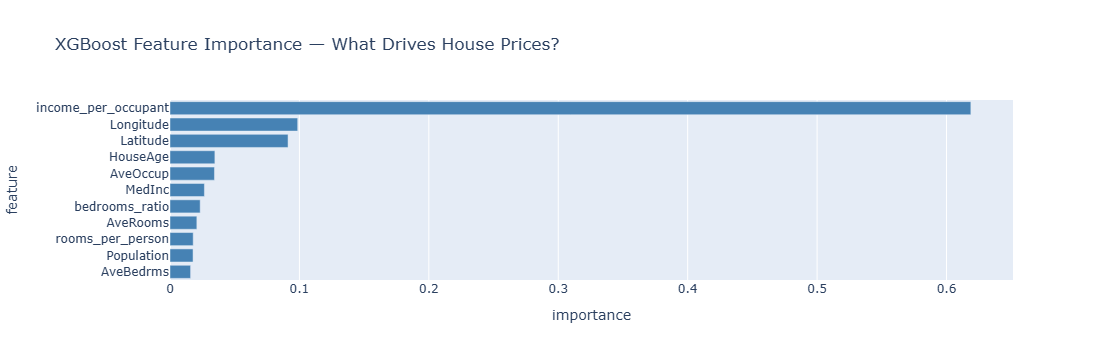

In [14]:
# Visualise feature importance — which columns matter most to XGBoost?
import plotly.express as px
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

fig = px.bar(
    importance,
    x='importance',
    y='feature',
    orientation='h',
    title='XGBoost Feature Importance — What Drives House Prices?',
    color_discrete_sequence=['steelblue']
)
fig.show()